<a href="https://colab.research.google.com/github/ExcWasHere/PCVK_2026/blob/main/Week6_Exc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 -  Spacial Filter

## Filter Practical

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def convolution2d(image, kernel, stride, padding):

    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    out_height = (img_height - kernel_height) // stride + 1
    out_width = (img_width - kernel_width) // stride + 1

    output_image = np.zeros((out_height, out_width), dtype=np.float32)

    for y in range(out_height):
        for x in range(out_width):
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            roi = image[y_start:y_end, x_start:x_end]

            output_image[y, x] = np.sum(roi * kernel)

    return output_image

In [4]:
img = cv.imread('/content/drive/MyDrive/Work/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [5]:
kernel_sharpen = np.array([[0,-1,0],
                          [-1,5,-1],
                          [0,-1,0]])

In [6]:
kernel_emboss = np.array([[-2,-1,0],
                          [-1,1,1],
                          [0,1,2]])

In [7]:
kernel_leftSobelEdgeDetection = np.array([[1,0,-1],
                                          [2,0,-2],
                                          [1,0,-1]])

In [8]:
kernel_cannyEdgeDetection = np.array([[-1,-1,-1],
                                      [-1,8,-1],
                                      [-1,-1,-1]])

In [9]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()


In [10]:
img_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
img_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
img_sobel = convolution2d(img_gray, kernel_leftSobelEdgeDetection, stride=1, padding=1)
img_canny = convolution2d(img_gray, kernel_cannyEdgeDetection, stride=1, padding=1)
img_gaussian = convolution2d(img_gray, gauss_kernel, stride=1, padding=10)

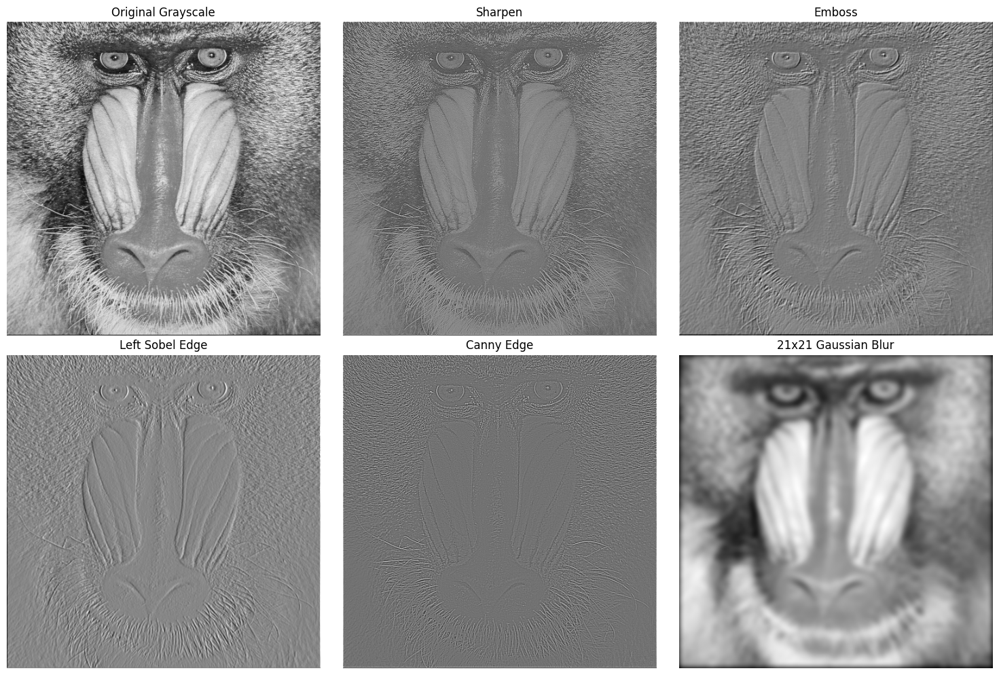

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

images = [img_gray, img_sharpen, img_emboss, img_sobel, img_canny, img_gaussian]
titles = ['Original Grayscale', 'Sharpen', 'Emboss', 'Left Sobel Edge', 'Canny Edge', '21x21 Gaussian Blur']

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

## FILTER LIBRARY AND MODERN FILTER

### Experiment 1

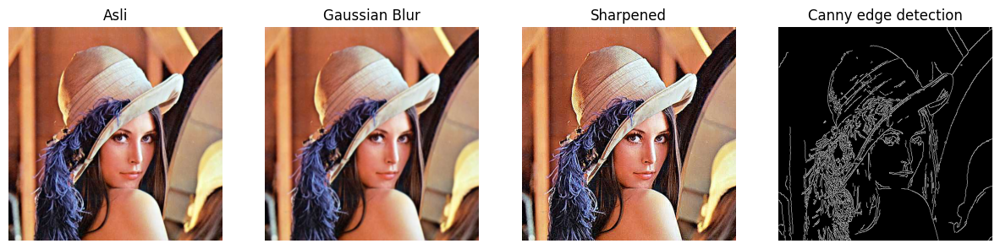

In [12]:
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images,titles)):
    if len (img.shape) == 2: #grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap ="gray")
    else: #color
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
  plt.show()
img = cv.imread("/content/drive/MyDrive/Work/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny edge detection"])

### Experiment 2

In [13]:
bilateral = cv.bilateralFilter(img, 50,100,100)

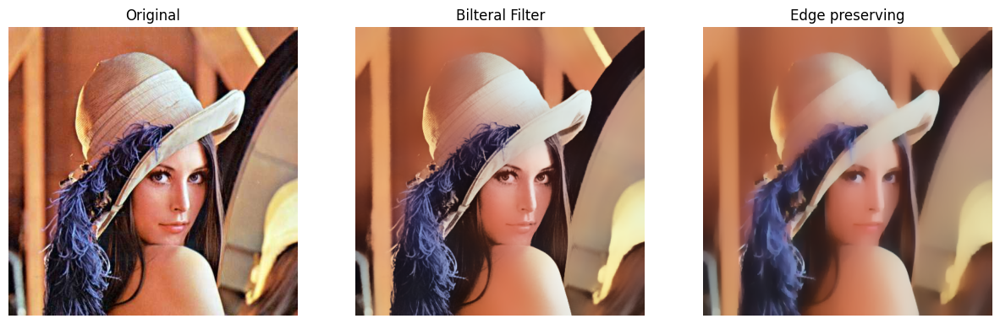

In [14]:
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Original", "Bilteral Filter", "Edge preserving"])

### Experiment 3


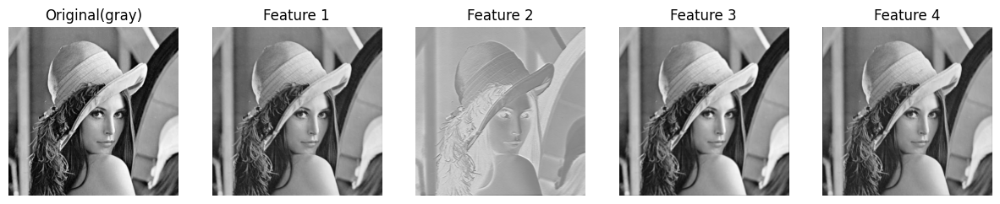

In [15]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    return self.conv1(x)

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
  features = model(img_tensor)

feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Original(gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])


The resulting feature maps change every time we run the code because the convolutional filters are initialized with random weights

### Experiment 4

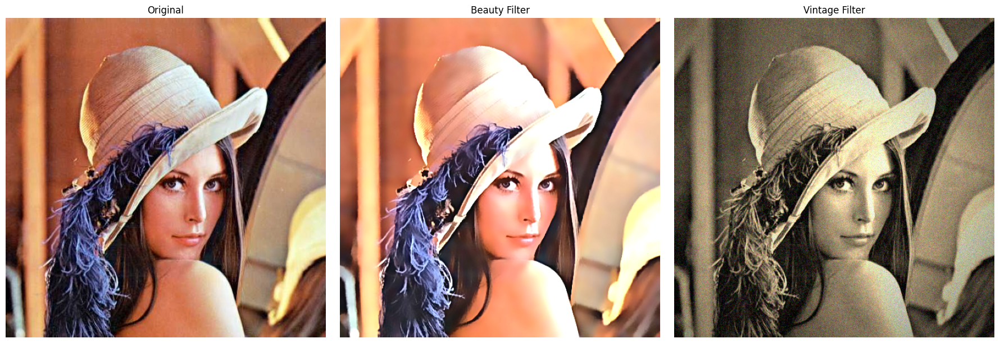

In [16]:
# 1. Beauty Filter
#===============

smooth = cv.bilateralFilter (img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2 # contrast
beta = 15 #brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Vintage filter
#==================
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
  vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
beauty_rgb = cv.cvtColor(beauty, cv.COLOR_BGR2RGB)
vintage_rgb = cv.cvtColor(old_img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(beauty_rgb)
axes[1].set_title('Beauty Filter')
axes[1].axis('off')

axes[2].imshow(vintage_rgb)
axes[2].set_title('Vintage Filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Experiment 5

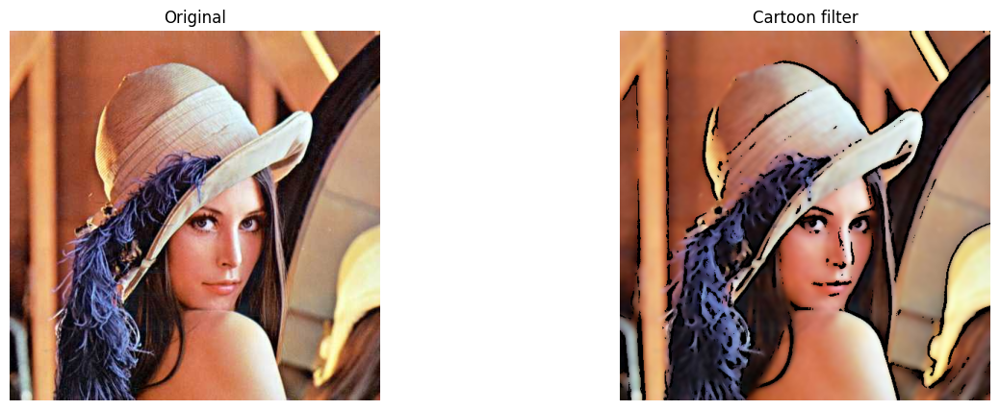

In [17]:
# Filter Cartoon

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Original", "Cartoon filter"])

### Experiment 6

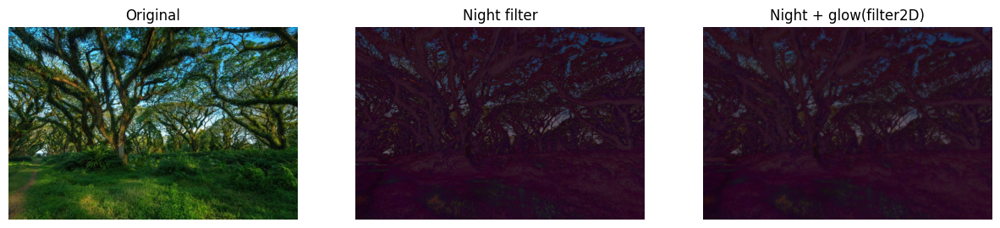

In [18]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/Work/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Original", "Night filter","Night + glow(filter2D)"])


### Experiment 7

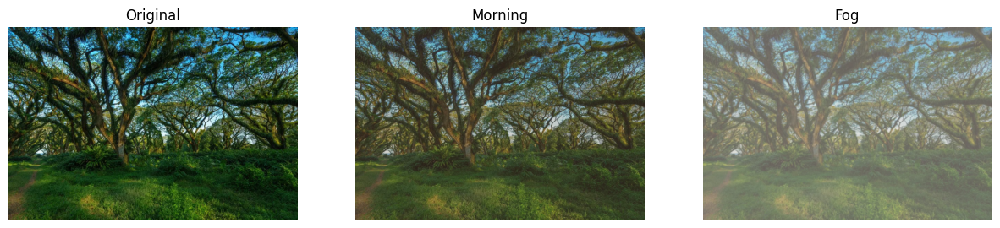

In [19]:
# Filter morning and fog

alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70,120))
morning = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
fog = cv.filter2D(morning, -1, kernel)

white_layer = np.full_like(morning, 255)
fog = cv.addWeighted(fog, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, morning, fog], ["Original", "Morning", "Fog"])

## Practical Assignment

### Task 1: Analytical


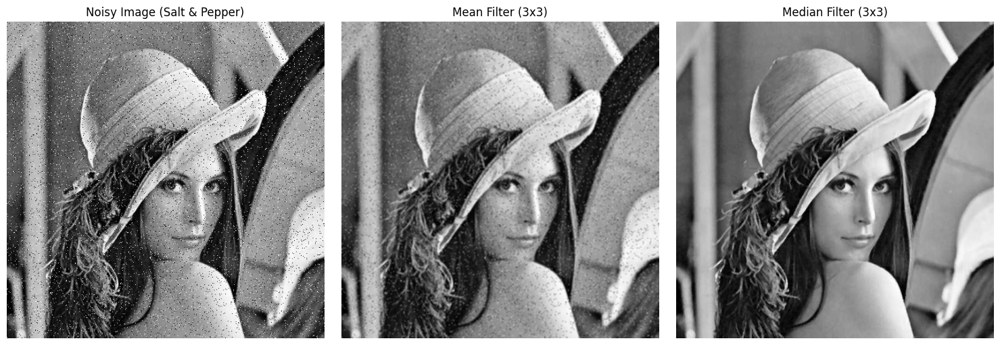

In [20]:
def add_salt_and_pepper_noise(image, prob=0.05):
    noisy_img = np.copy(image)

    random_matrix = np.random.rand(*noisy_img.shape)

    noisy_img[random_matrix < prob / 2] = 0

    noisy_img[random_matrix > 1 - (prob / 2)] = 255
    return noisy_img

img_gray = cv.imread('/content/drive/MyDrive/Work/lena.jpg', cv.IMREAD_GRAYSCALE)
img_noisy = add_salt_and_pepper_noise(img_gray, prob=0.05)

mean_filtered = cv.blur(img_noisy, (3, 3))
median_filtered = cv.medianBlur(img_noisy, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title('Noisy Image (Salt & Pepper)')
axes[1].imshow(mean_filtered, cmap='gray')
axes[1].set_title('Mean Filter (3x3)')
axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title('Median Filter (3x3)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

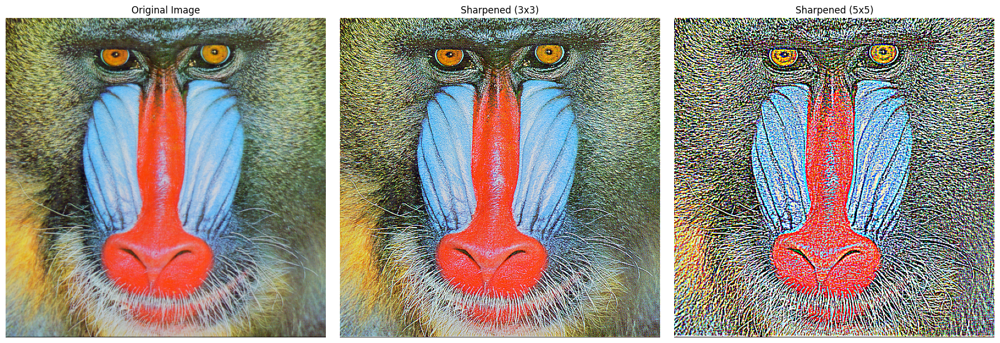

In [21]:
img_color = cv.imread('/content/drive/MyDrive/Work/mandrill.tiff')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

kernel_3x3 = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])

kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, 25, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1]])

sharpened_3x3 = cv.filter2D(img_rgb, -1, kernel_3x3)
sharpened_5x5 = cv.filter2D(img_rgb, -1, kernel_5x5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[1].imshow(sharpened_3x3)
axes[1].set_title('Sharpened (3x3)')
axes[2].imshow(sharpened_5x5)
axes[2].set_title('Sharpened (5x5)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

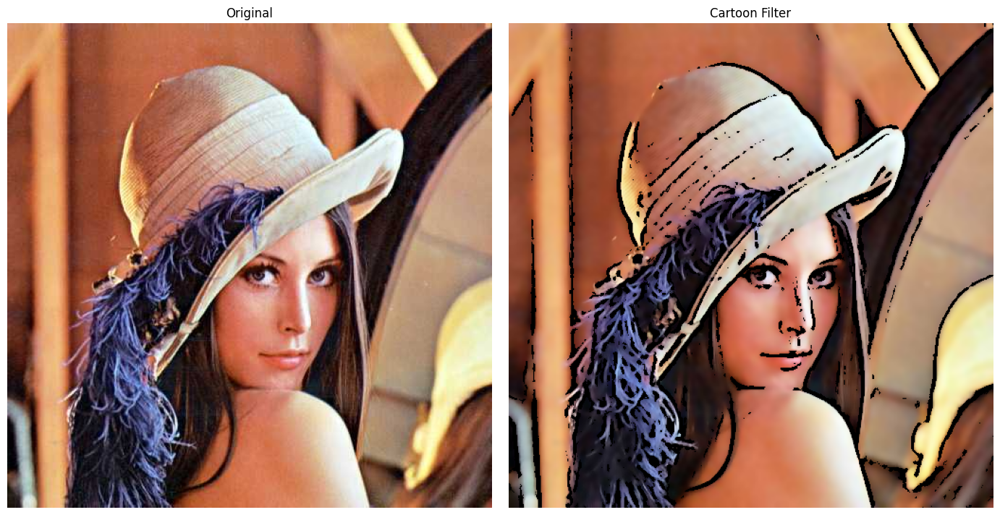

In [22]:
def cartoon(image):
    color_smoothed = cv.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blurred = cv.medianBlur(gray, 5)

    edges = cv.adaptiveThreshold(gray_blurred, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    edges_color = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    cartoon_result = cv.bitwise_and(color_smoothed, edges_color)

    return cartoon_result
img_color = cv.imread('/content/drive/MyDrive/Work/lena.jpg')
img_cartoon = cartoon(img_color)

original_display = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
cartoon_display = cv.cvtColor(img_cartoon, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(original_display)
axes[0].set_title('Original')
axes[1].imshow(cartoon_display)
axes[1].set_title('Cartoon Filter')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()